In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

from src.dataloading.gnndataloader import GNNDataLoader

In [2]:
epidata_nuts2 = GNNDataLoader('influenza', data_env, nuts_level='nuts2', min_date='2006-05-15',max_date='2020-06-02', include_population=False, horizon_size = 1, horizon_leadtime = 3, sequence_length=12)
epidata_nuts2.add_time_features()
epidata_nuts2.set_splits()
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags = 1)
epidata_nuts2.finalize()

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-01-30 (+15 weeks)


EpiDataLoader(disease=influenza, nuts_level=nuts2, min_date=2006-01-30, max_date=2020-06-02, horizon_size=1, horizon_leadtime=3, sequence_length=12)

In [3]:
epidata_nuts2_id  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'identity_graph').construct_dataloaders()
# epidata_nuts2_bn1  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_self0').construct_dataloaders()
epidata_nuts2_bn2  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_selfmn').construct_dataloaders()
# epidata_nuts2_gm1 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_dense').construct_dataloaders()
# epidata_nuts2_gm2 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_sparse').construct_dataloaders()

Dataloader temporal windowing: extending data collection from 2006-01-30 to 2005-10-17 (+15 weeks)
Dataloader temporal windowing: extending data collection from 2006-01-30 to 2005-10-17 (+15 weeks)


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 1])
➡️  Ground truth shape: torch.Size([38, 1])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=(38, 3, 12), y=(38, 1), edge_index=(2, 210), edge_weight=(210,))
Epoch 1 train loss: 0.8862, val loss: 1.9609 ✓ (new best)
Epoch 2 train loss: 0.8502, val loss: 1.7849 ✓ (new best)
Epoch 3 train loss: 0.8082, val loss: 1.6291 ✓ (new best)
Epoch 4 train loss: 0.7653, val loss: 1.4933 ✓ (new best)
Epoch 5 train loss: 0.7378, val loss: 1.3981 ✓ (new best)
Epoch 6 train loss: 0.7093, val loss: 1.3328 ✓ (new best)
Epoch 7 train loss: 0.6917, val loss: 1.3059 ✓ (new best)
Epoch 8 train loss: 0.6766, val loss: 1.2588 ✓ (new best)
Epoch 9 train loss: 0.6633, val loss: 1.2267 ✓ (new best)
Epoch 10 train loss: 0.6497, val loss: 1.1907 ✓ (new best)
Epoch 11 train loss: 0.6441, val loss: 1.1819 ✓ (new best)
Epoch 12 train loss: 0.6340, val loss: 1.1473 ✓ (new best)
Epoch 13 train loss: 0.6152, val loss: 1.1150

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 1])
➡️  Ground truth shape: torch.Size([38, 1])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=(38, 3, 12), y=(38, 1), edge_index=(2, 38), edge_weight=(38,))
Epoch 1 train loss: 0.8625, val loss: 1.8988 ✓ (new best)
Epoch 2 train loss: 0.8161, val loss: 1.7082 ✓ (new best)
Epoch 3 train loss: 0.7667, val loss: 1.5266 ✓ (new best)
Epoch 4 train loss: 0.7129, val loss: 1.3671 ✓ (new best)
Epoch 5 train loss: 0.6880, val loss: 1.2609 ✓ (new best)
Epoch 6 train loss: 0.6512, val loss: 1.1761 ✓ (new best)
Epoch 7 train loss: 0.6400, val loss: 1.1439 ✓ (new best)
Epoch 8 train loss: 0.6252, val loss: 1.0938 ✓ (new best)
Epoch 9 train loss: 0.6200, val loss: 1.0771 ✓ (new best)
Epoch 10 train loss: 0.6120, val loss: 1.0475 ✓ (new best)
Epoch 11 train loss: 0.5918, val loss: 1.0111 ✓ (new best)
Epoch 12 train loss: 0.6019, val loss: 1.0326 (patience: 1/15)
Epoch 13 train loss: 0.5922, val loss: 0.99

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 1'}, ylabel='incidence'>],
       dtype=object))

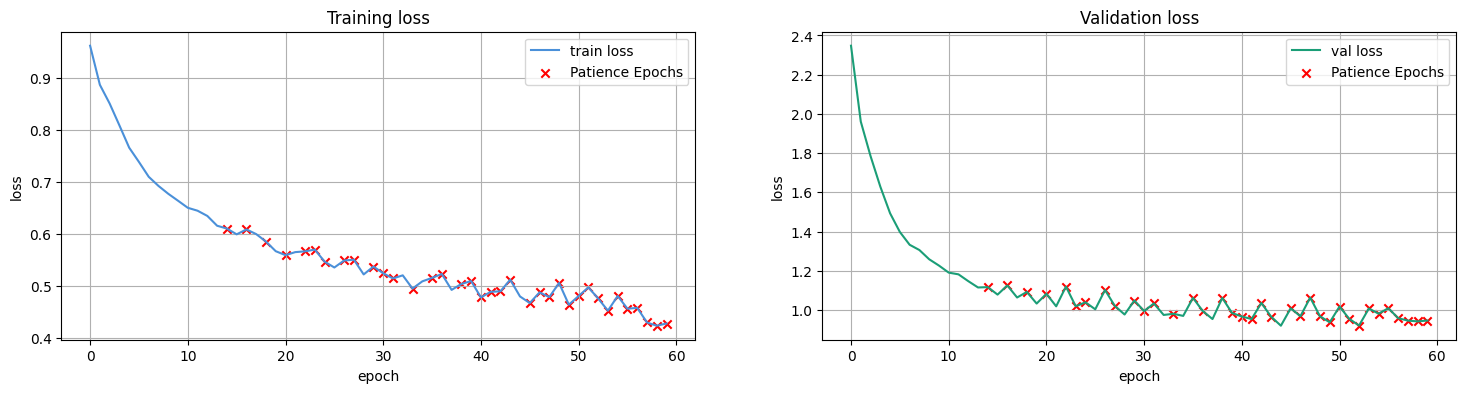

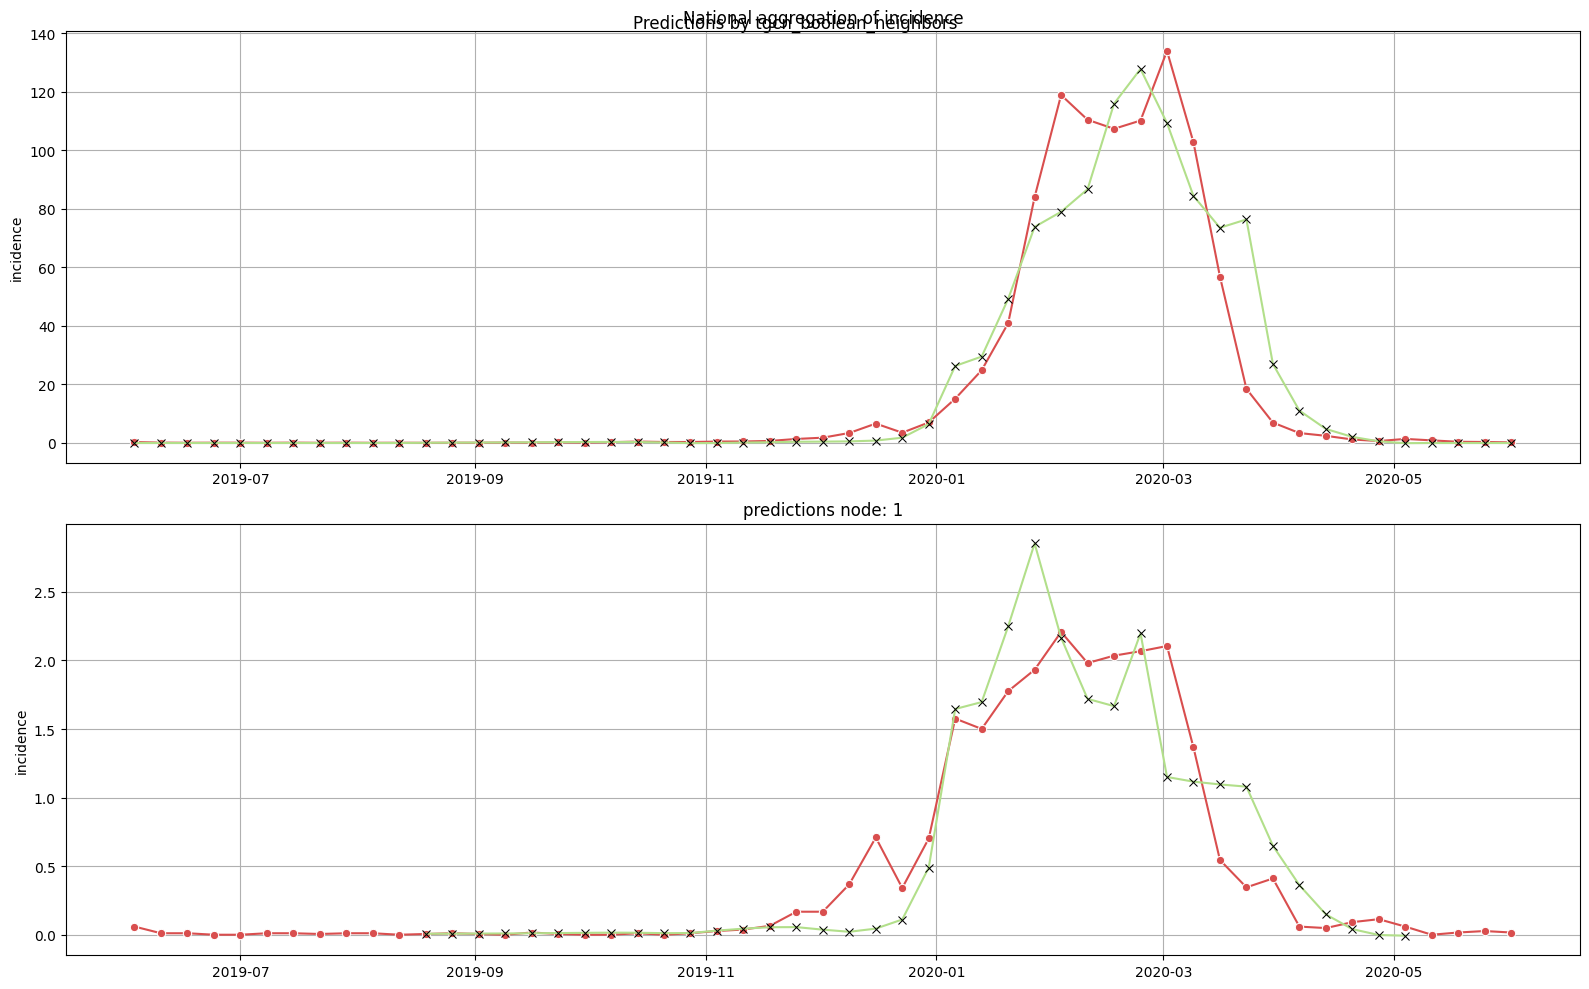

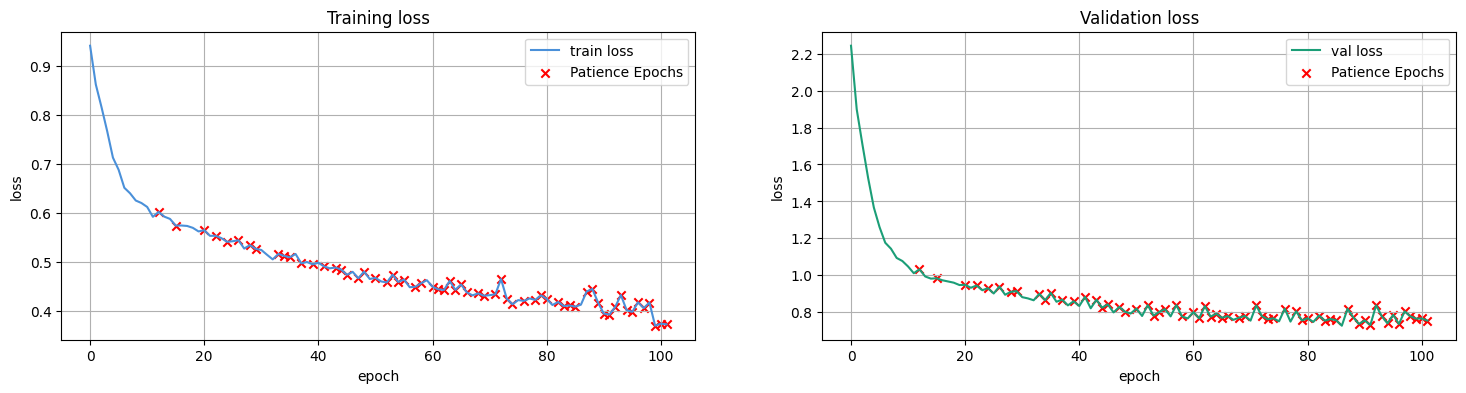

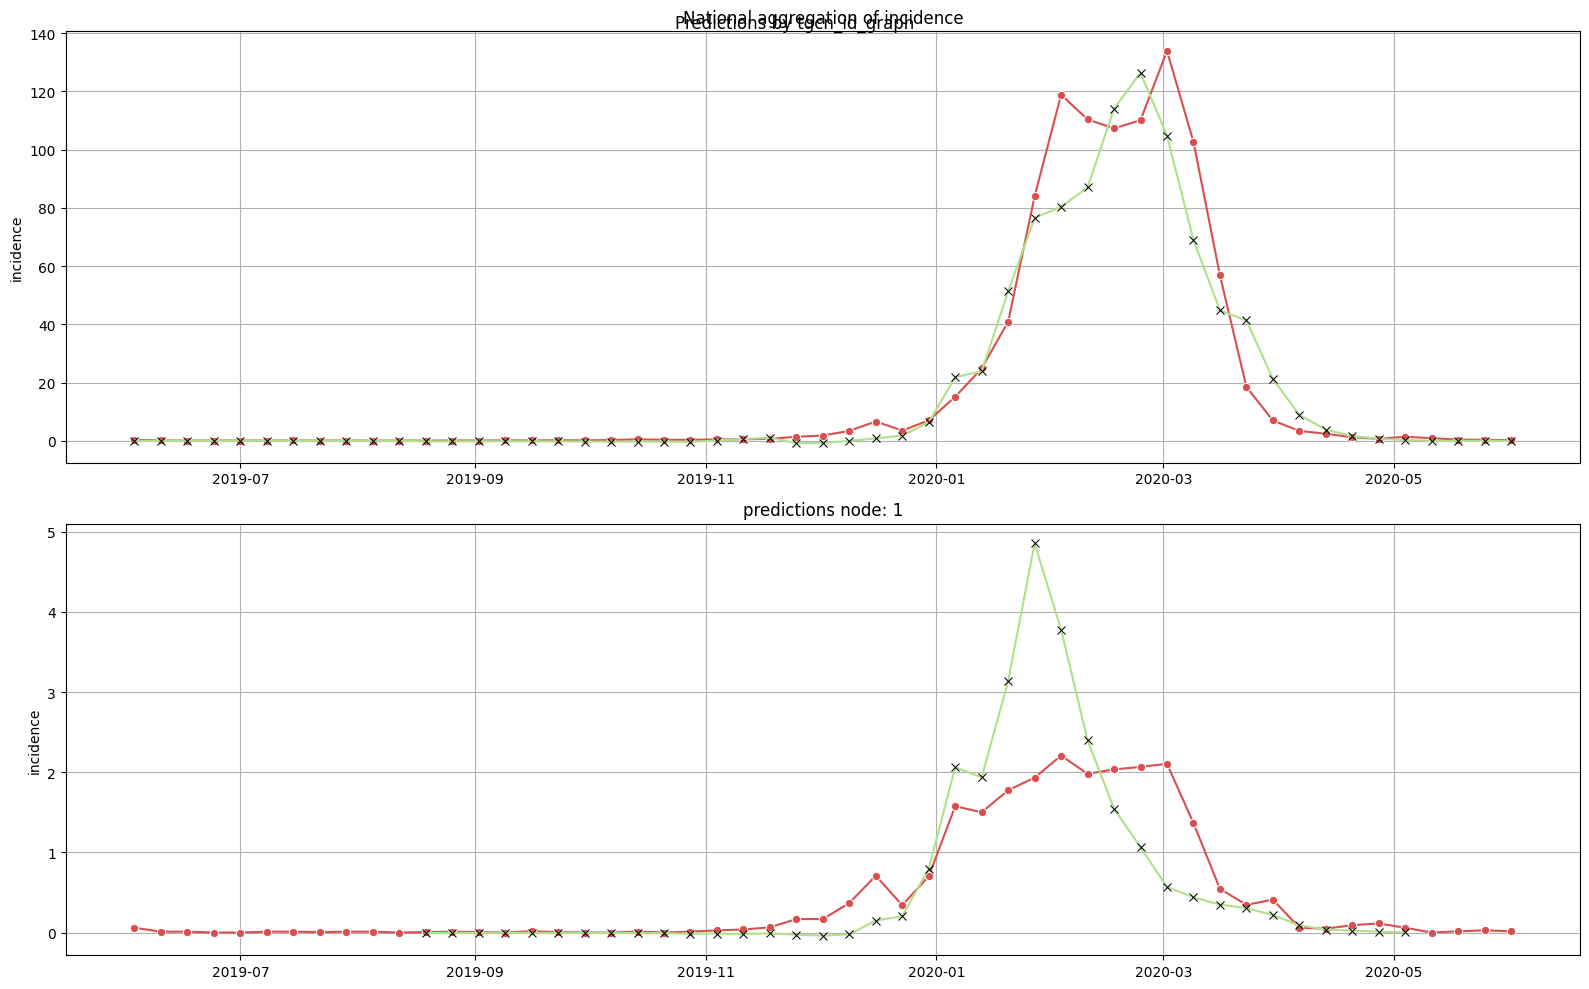

In [4]:
from src.models.spatiotemporal_baseline import TGCNModel

n_epochs = 150
lr       = 0.0001
min_delta= 0.001

ml2_bn = TGCNModel(name = f'tgcn_boolean_neighbors', dataloader=epidata_nuts2_bn2)
ml2_bn.set_model_hparams()
ml2_bn.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler='plateau', min_delta = min_delta, loss = 'mse')
ml2_bn.run_snapshot(debug=True)
ml2_bn.train(verbose=2)
ml2_bn.forecast()
ml2_bn.show_forecasts(dataset='test',target_h = 0)


ml2_id = TGCNModel(name = f'tgcn_id_graph', dataloader=epidata_nuts2_id)
ml2_id.set_model_hparams()
ml2_id.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler='plateau', min_delta = min_delta, loss = 'mse')
ml2_id.run_snapshot(debug=True)
ml2_id.train(verbose=2)
ml2_id.forecast()
ml2_id.show_forecasts(dataset='test',target_h = 0)



